In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [5]:
df = pd.read_csv('Mall_Customers.csv')

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
label = LabelEncoder()

df['Gender'] = label.fit_transform(df['Gender'])

In [9]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [13]:
model = KMeans(n_clusters=2)
res = model.fit_predict(df)

In [14]:
df['result'] = res

In [17]:
df.head(100)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),result
0,1,1,19,15,39,1
1,2,1,21,15,81,1
2,3,0,20,16,6,1
3,4,0,23,16,77,1
4,5,0,31,17,40,1
...,...,...,...,...,...,...
95,96,1,24,60,52,1
96,97,0,47,60,47,1
97,98,0,27,60,50,1
98,99,1,48,61,42,1


In [19]:
clusters = df.groupby('result')

In [20]:
clusters.groups

{0: [99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, ...], 1: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98]}

In [22]:
clusters.get_group(1)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),result
0,1,1,19,15,39,1
1,2,1,21,15,81,1
2,3,0,20,16,6,1
3,4,0,23,16,77,1
4,5,0,31,17,40,1
...,...,...,...,...,...,...
94,95,0,32,60,42,1
95,96,1,24,60,52,1
96,97,0,47,60,47,1
97,98,0,27,60,50,1


In [23]:
cluster_1 = df[df['result']==1]
cluster_0 = df[df['result']==0]

In [24]:
cluster_0

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),result
99,100,1,20,61,49,0
100,101,0,23,62,41,0
101,102,0,49,62,48,0
102,103,1,67,62,59,0
103,104,1,26,62,55,0
...,...,...,...,...,...,...
195,196,0,35,120,79,0
196,197,0,45,126,28,0
197,198,1,32,126,74,0
198,199,1,32,137,18,0


In [ ]:
res = []
for i in range(1,6):
    model = KMeans(n_clusters=i)
    model.fit_predict(df)
    res.append(model.inertia_)

In [29]:
res

[975562.0550000002,
 387065.7137713771,
 272141.95140959613,
 228278.87324732158,
 187896.9121826043]

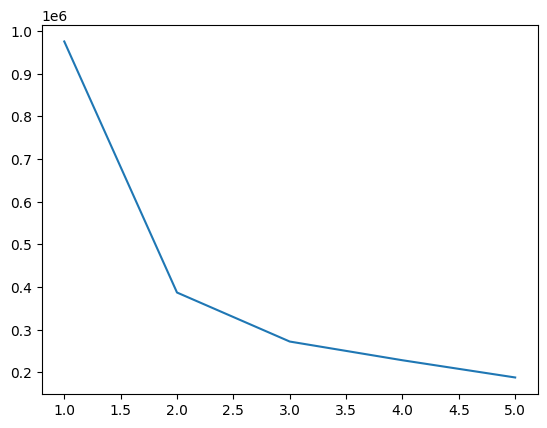

In [30]:
import matplotlib.pyplot as plt
plt.plot(range(1,6),res)